CF 계열 모델들 모델링하고 metric들 뽑아보기

In [ ]:
import sys
sys.path.insert(0, '../../src')

import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv(dotenv_path='../../.env')

DB_URL = (
    f"postgresql://{os.getenv('POSTGRES_USER', 'movie_user')}"
    f":{os.getenv('POSTGRES_PASSWORD', 'movie_pass')}"
    f"@{os.getenv('POSTGRES_HOST', 'localhost')}"
    f":{os.getenv('POSTGRES_PORT', '5432')}"
    f"/{os.getenv('POSTGRES_DB', 'movie_recommendation')}"
)

engine = create_engine(DB_URL)
print('connected:', engine.url.render_as_string(hide_password=True))

In [2]:
# import sqlalchemy as sa

# # 테이블 목록 확인
# inspector = sa.inspect(engine)
# print('tables:', inspector.get_table_names())

In [ ]:
from pathlib import Path
from core.db.loader import load_ml_ratings, load_ml_movies

CACHE_DIR = Path('../../data/cache')

In [ ]:
ratings = load_ml_ratings(cache_dir=CACHE_DIR)
print(ratings.shape)
ratings.head()

# EDA

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print(f"총 평점 수: {len(ratings):,}")
print(f"유저 수:   {ratings['user_id'].nunique():,}")
print(f"영화 수:   {ratings['movie_id'].nunique():,}")
print(f"\n평점 통계:")
print(ratings['rating'].describe())

총 평점 수: 32,000,204
유저 수:   200,948
영화 수:   84,432

평점 통계:
count    3.200020e+07
mean     3.540396e+00
std      1.058986e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


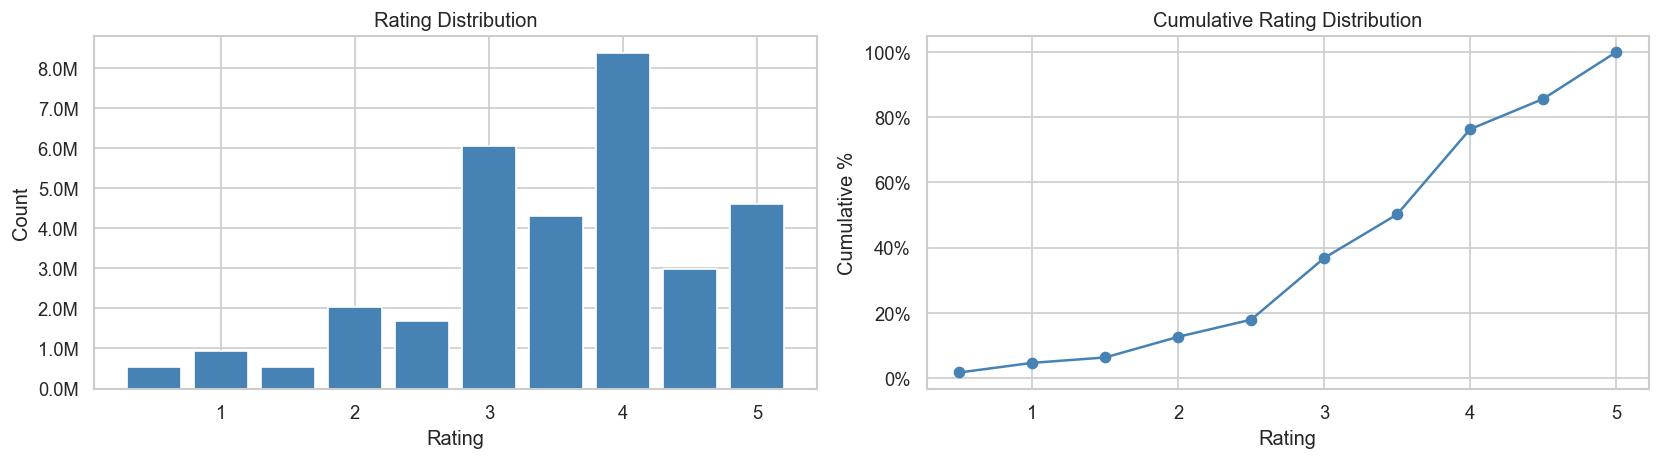

평균 평점: 3.540 | 중앙값: 3.5


In [6]:
## 1. 평점 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 히스토그램
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, width=0.4, color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# 누적 분포
sorted_ratings = rating_counts.sort_index()
cumulative = sorted_ratings.cumsum() / sorted_ratings.sum()
axes[1].plot(cumulative.index, cumulative.values, marker='o', color='steelblue')
axes[1].set_title('Cumulative Rating Distribution')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Cumulative %')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

print(f"평균 평점: {ratings['rating'].mean():.3f} | 중앙값: {ratings['rating'].median():.1f}")

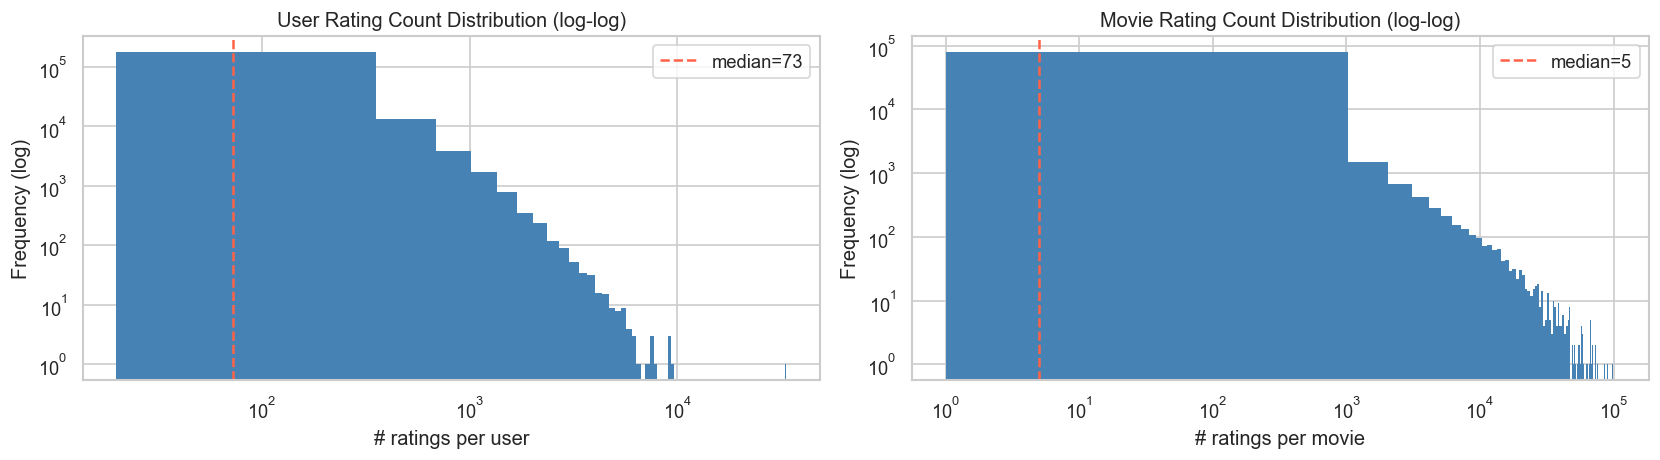

유저당 평점 수  — median: 73, mean: 159.2, max: 33,332
영화당 평점 수  — median: 5, mean: 379.0, max: 102,929
  유저 25th pctile: 36개
  유저 50th pctile: 73개
  유저 75th pctile: 167개
  유저 90th pctile: 364개
  유저 99th pctile: 1290개


In [7]:
## 2. 유저/아이템 활동 분포 (Long-tail)
user_counts = ratings.groupby('user_id').size()
movie_counts = ratings.groupby('movie_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, counts, label in zip(axes, [user_counts, movie_counts], ['User', 'Movie']):
    ax.hist(counts, bins=100, color='steelblue', edgecolor='none', log=True)
    ax.set_xscale('log')
    ax.set_title(f'{label} Rating Count Distribution (log-log)')
    ax.set_xlabel(f'# ratings per {label.lower()}')
    ax.set_ylabel('Frequency (log)')
    median = counts.median()
    ax.axvline(median, color='tomato', linestyle='--', label=f'median={median:.0f}')
    ax.legend()

plt.tight_layout()
plt.show()

print(f"유저당 평점 수  — median: {user_counts.median():.0f}, mean: {user_counts.mean():.1f}, max: {user_counts.max():,}")
print(f"영화당 평점 수  — median: {movie_counts.median():.0f}, mean: {movie_counts.mean():.1f}, max: {movie_counts.max():,}")

# 분위수
for q in [0.25, 0.5, 0.75, 0.9, 0.99]:
    print(f"  유저 {q*100:.0f}th pctile: {user_counts.quantile(q):.0f}개")

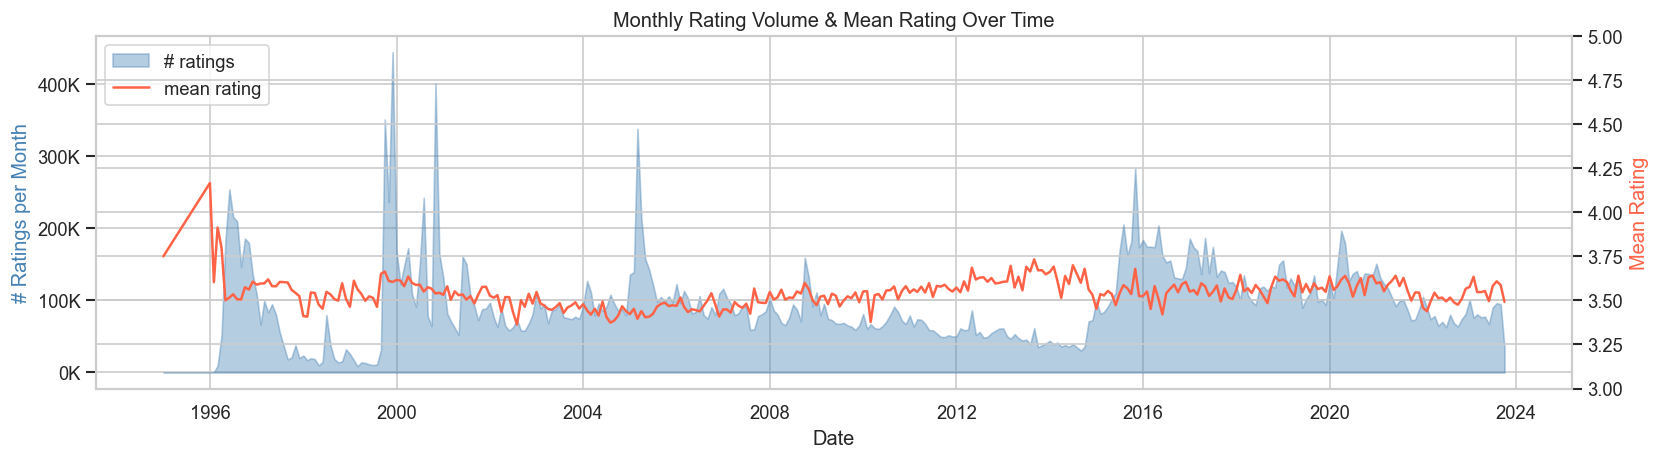

In [8]:
## 3. 시간대별 평점 추이
ratings_time = ratings.copy()
ratings_time['year_month'] = ratings_time['rated_at'].dt.to_period('M')
monthly = ratings_time.groupby('year_month').agg(
    count=('rating', 'size'),
    mean_rating=('rating', 'mean')
).reset_index()
monthly['year_month'] = monthly['year_month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.fill_between(monthly['year_month'], monthly['count'], alpha=0.4, color='steelblue', label='# ratings')
ax1.set_ylabel('# Ratings per Month', color='steelblue')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

ax2.plot(monthly['year_month'], monthly['mean_rating'], color='tomato', linewidth=1.5, label='mean rating')
ax2.set_ylabel('Mean Rating', color='tomato')
ax2.set_ylim(3, 5)

ax1.set_title('Monthly Rating Volume & Mean Rating Over Time')
ax1.set_xlabel('Date')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
## 4. Sparsity 분석
n_users = ratings['user_id'].nunique()
n_movies = ratings['movie_id'].nunique()
n_ratings = len(ratings)
sparsity = 1 - n_ratings / (n_users * n_movies)

print(f"User-Item Matrix: {n_users:,} × {n_movies:,}")
print(f"총 가능한 평점 수: {n_users * n_movies:,}")
print(f"실제 평점 수:     {n_ratings:,}")
print(f"Sparsity:        {sparsity:.4%}")

movies = load_ml_movies(cache_dir=CACHE_DIR)
print(f"\n영화 테이블: {len(movies):,} rows")

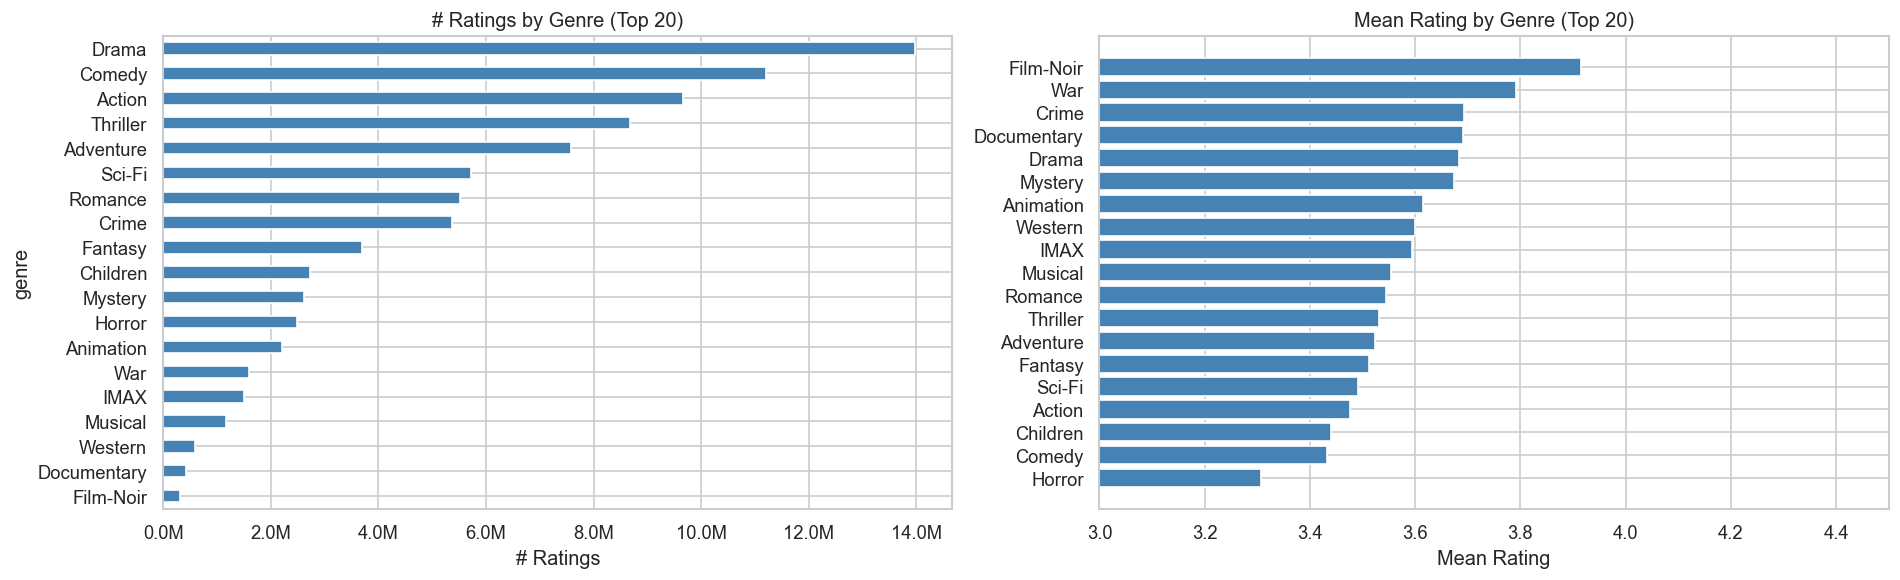

In [10]:
## 5. 장르별 평점 수 & 평균 평점
ratings_with_genre = ratings.merge(movies[['movie_id', 'genres']], on='movie_id', how='inner')
genre_exploded = (
    ratings_with_genre.assign(genre=ratings_with_genre['genres'].str.split('|'))
    .explode('genre')
)
genre_exploded = genre_exploded[genre_exploded['genre'] != '(no genres listed)']

genre_stats = genre_exploded.groupby('genre').agg(
    count=('rating', 'size'),
    mean_rating=('rating', 'mean')
).sort_values('count', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

genre_stats['count'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('# Ratings by Genre (Top 20)')
axes[0].set_xlabel('# Ratings')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

genre_stats_sorted = genre_stats.sort_values('mean_rating', ascending=False)
bars = axes[1].barh(genre_stats_sorted.index, genre_stats_sorted['mean_rating'], color='steelblue')
axes[1].invert_yaxis()
axes[1].set_title('Mean Rating by Genre (Top 20)')
axes[1].set_xlabel('Mean Rating')
axes[1].set_xlim(3, 4.5)

plt.tight_layout()
plt.show()

# 데이터 전처리 & Train/Test Split

Cold-start 방지를 위해 최소 평점 기준 필터링 후 시간 기반 분리 (마지막 20%를 test로 사용)

In [11]:
MIN_USER_RATINGS = 20   # 유저당 최소 평점 수
MIN_MOVIE_RATINGS = 50  # 영화당 최소 평점 수

# 필터링 (반복적으로 수렴할 때까지)
filtered = ratings.copy()
prev_len = -1
iteration = 0
while len(filtered) != prev_len:
    prev_len = len(filtered)
    u_keep = filtered.groupby('user_id').size()
    filtered = filtered[filtered['user_id'].isin(u_keep[u_keep >= MIN_USER_RATINGS].index)]
    m_keep = filtered.groupby('movie_id').size()
    filtered = filtered[filtered['movie_id'].isin(m_keep[m_keep >= MIN_MOVIE_RATINGS].index)]
    iteration += 1

print(f"필터링 후 ({iteration} iterations):")
print(f"  평점 수: {len(filtered):,}  ({len(filtered)/len(ratings)*100:.1f}%)")
print(f"  유저 수: {filtered['user_id'].nunique():,}")
print(f"  영화 수: {filtered['movie_id'].nunique():,}")
sparsity_filtered = 1 - len(filtered) / (filtered['user_id'].nunique() * filtered['movie_id'].nunique())
print(f"  Sparsity: {sparsity_filtered:.4%}")

필터링 후 (3 iterations):
  평점 수: 31,491,369  (98.4%)
  유저 수: 200,559
  영화 수: 16,025
  Sparsity: 99.0202%


In [12]:
# 시간 기반 train/test split  (유저별로 마지막 20%를 test)
filtered = filtered.sort_values(['user_id', 'rated_at'])

def temporal_split(df, test_ratio=0.2):
    df = df.sort_values(['user_id', 'rated_at'])
    df['rank'] = df.groupby('user_id').cumcount()
    df['total'] = df.groupby('user_id')['user_id'].transform('count')
    df['is_test'] = df['rank'] >= (df['total'] * (1 - test_ratio)).astype(int)
    train = df[~df['is_test']].drop(columns=['rank', 'total', 'is_test'])
    test  = df[ df['is_test']].drop(columns=['rank', 'total', 'is_test'])
    return train, test

train_df, test_df = temporal_split(filtered, test_ratio=0.2)
print(f"Train: {len(train_df):,} | Test: {len(test_df):,}")
print(f"Train date range: {train_df['rated_at'].min().date()} ~ {train_df['rated_at'].max().date()}")
print(f"Test  date range: {test_df['rated_at'].min().date()} ~ {test_df['rated_at'].max().date()}")

Train: 25,113,875 | Test: 6,377,494
Train date range: 1995-01-09 ~ 2023-10-13
Test  date range: 1996-02-02 ~ 2023-10-13


In [13]:
# Surprise Dataset 구성
from surprise import Dataset, Reader

RATING_SCALE = (0.5, 5.0)
reader = Reader(rating_scale=RATING_SCALE)

surprise_train = Dataset.load_from_df(train_df[['user_id', 'movie_id', 'rating']], reader).build_full_trainset()
surprise_testset = list(zip(test_df['user_id'], test_df['movie_id'], test_df['rating']))

print(f"Surprise trainset: {surprise_train.n_ratings:,} ratings")
print(f"Surprise testset:  {len(surprise_testset):,} ratings")

Surprise trainset: 25,113,875 ratings
Surprise testset:  6,377,494 ratings


# CF 모델링

| 모델 | 유형 | 데이터 | 특징 |
|---|---|---|---|
| UserKNN | Memory-based | 샘플 10K 유저 | 유저 유사도 기반 |
| ItemKNN | Memory-based | 샘플 10K 유저 | 아이템 유사도 기반 |
| SVD (Funk) | Model-based | 전체 | 잠재 요인 분해 |
| SVD++ | Model-based | 전체 | SVD + implicit feedback |
| NMF | Model-based | 전체 | 비음수 행렬 분해 |

## Memory-based CF 스케일 한계

Memory-based CF는 예측 시 전체 유저(또는 아이템) 간 유사도를 탐색하는 구조라 데이터 규모에 민감하다.

- **UserKNN**: 유저 200K명 기준 유사도 연산 최대 O(n²) → 전체 실행 시 수십 분 이상 소요
- **ItemKNN**: 아이템 16K개 기준으로 UserKNN보다는 빠르지만 동일한 구조적 한계 존재
- Surprise 라이브러리는 순수 Python/Cython 구현으로 대규모 데이터에 최적화되지 않음

> **KNN 계열은 무작위 샘플링한 10K 유저 subset으로만 실행.** SVD 계열은 전체 데이터로 학습하므로 메트릭을 직접 비교할 때 이 점을 감안할 것.

In [14]:
import time
from surprise import KNNBasic, KNNWithMeans, SVD, SVDpp, NMF
from surprise import accuracy as surprise_accuracy

results = {}

def train_and_eval(name, algo, trainset, testset):
    t0 = time.time()
    algo.fit(trainset)
    elapsed_fit = time.time() - t0

    t0 = time.time()
    preds = algo.test(testset)
    elapsed_test = time.time() - t0

    rmse = surprise_accuracy.rmse(preds, verbose=False)
    mae  = surprise_accuracy.mae(preds,  verbose=False)
    print(f"[{name:12s}]  RMSE={rmse:.4f}  MAE={mae:.4f}  fit={elapsed_fit:.1f}s  test={elapsed_test:.1f}s")
    return {'algo': algo, 'preds': preds, 'rmse': rmse, 'mae': mae}

print("=== Rating Prediction (RMSE / MAE) ===\n")

=== Rating Prediction (RMSE / MAE) ===



In [ ]:
# KNN용 샘플 데이터셋 구성 (200K 유저 전체는 수십 분 이상 소요)
KNN_SAMPLE_USERS = 10_000
rng = np.random.default_rng(42)
sampled_users = rng.choice(filtered['user_id'].unique(), size=KNN_SAMPLE_USERS, replace=False)

knn_train_df = train_df[train_df['user_id'].isin(sampled_users)]
knn_test_df  = test_df[test_df['user_id'].isin(sampled_users)]

knn_surprise_train = Dataset.load_from_df(
    knn_train_df[['user_id', 'movie_id', 'rating']], reader
).build_full_trainset()
knn_surprise_testset = list(zip(knn_test_df['user_id'], knn_test_df['movie_id'], knn_test_df['rating']))

print(f"KNN 샘플: {KNN_SAMPLE_USERS:,} 유저 / 전체 {filtered['user_id'].nunique():,} 유저")
print(f"KNN trainset: {knn_surprise_train.n_ratings:,} ratings")
print(f"KNN testset:  {len(knn_surprise_testset):,} ratings")

In [ ]:
## Memory-based CF (샘플 10K 유저)
knn_cfg = {'k': 40, 'min_k': 5, 'sim_options': {'name': 'pearson_baseline', 'shrinkage': 100}}

results['UserKNN'] = train_and_eval(
    'UserKNN',
    KNNWithMeans(user_based=True,  **knn_cfg),
    knn_surprise_train, knn_surprise_testset
)
results['ItemKNN'] = train_and_eval(
    'ItemKNN',
    KNNWithMeans(user_based=False, **knn_cfg),
    knn_surprise_train, knn_surprise_testset
)

In [ ]:
## Model-based CF: SVD variants & NMF
results['SVD'] = train_and_eval(
    'SVD',
    SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42),
    surprise_train, surprise_testset
)
results['SVD++'] = train_and_eval(
    'SVD++',
    SVDpp(n_factors=20, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42),
    surprise_train, surprise_testset
)
results['NMF'] = train_and_eval(
    'NMF',
    NMF(n_factors=50, n_epochs=50, random_state=42),
    surprise_train, surprise_testset
)

# Ranking Metrics: Precision@K / Recall@K / NDCG@K

평점 예측 오차(RMSE)가 낮다고 추천 품질이 좋은 건 아님.
유저가 실제로 높게 평가할 영화를 top-K에 넣는지를 평가.

In [ ]:
from collections import defaultdict

def ranking_metrics(predictions, k=10, threshold=4.0):
    """
    predictions: surprise algo.test() 결과
    threshold: 이 점수 이상이면 relevant로 간주
    """
    user_preds = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_preds[uid].append((est, true_r))

    precisions, recalls, ndcgs = [], [], []
    for uid, preds in user_preds.items():
        preds_sorted = sorted(preds, key=lambda x: x[0], reverse=True)[:k]
        top_k_relevant = sum(1 for est, true_r in preds_sorted if true_r >= threshold)
        total_relevant = sum(1 for _, true_r in preds if true_r >= threshold)

        precision = top_k_relevant / k
        recall    = top_k_relevant / total_relevant if total_relevant > 0 else 0
        precisions.append(precision)
        recalls.append(recall)

        # NDCG
        dcg  = sum((2**(true_r >= threshold) - 1) / np.log2(i + 2)
                   for i, (est, true_r) in enumerate(preds_sorted))
        ideal = sorted([true_r for _, true_r in preds if true_r >= threshold], reverse=True)[:k]
        idcg = sum((2**1 - 1) / np.log2(i + 2) for i in range(len(ideal)))
        ndcgs.append(dcg / idcg if idcg > 0 else 0)

    return {
        f'Precision@{k}': np.mean(precisions),
        f'Recall@{k}':    np.mean(recalls),
        f'NDCG@{k}':      np.mean(ndcgs),
    }

K = 10
print(f"=== Ranking Metrics @{K} (threshold=4.0) ===\n")
for name, res in results.items():
    metrics = ranking_metrics(res['preds'], k=K, threshold=4.0)
    results[name].update(metrics)
    print(f"[{name:12s}]  " + "  ".join(f"{mk}={mv:.4f}" for mk, mv in metrics.items()))

# 결과 비교 & 시각화

In [ ]:
metric_keys = ['rmse', 'mae', f'Precision@{K}', f'Recall@{K}', f'NDCG@{K}']
summary = pd.DataFrame(
    {name: {k: res[k] for k in metric_keys} for name, res in results.items()}
).T.round(4)
summary.index.name = 'Model'
summary

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

colors = plt.cm.tab10.colors[:len(summary)]

# RMSE / MAE
for i, metric in enumerate(['rmse', 'mae']):
    ax = axes[i]
    bars = ax.bar(summary.index, summary[metric], color=colors)
    ax.set_title(metric.upper())
    ax.set_ylabel(metric.upper())
    ax.set_ylim(summary[metric].min() * 0.95, summary[metric].max() * 1.05)
    for bar, val in zip(bars, summary[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{val:.4f}',
                ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', rotation=15)

# NDCG@K
ax = axes[2]
bars = ax.bar(summary.index, summary[f'NDCG@{K}'], color=colors)
ax.set_title(f'NDCG@{K}')
ax.set_ylabel(f'NDCG@{K}')
for bar, val in zip(bars, summary[f'NDCG@{K}']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{val:.4f}',
            ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', rotation=15)

plt.suptitle('CF Models — Metric Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 추천 예시 확인

베스트 모델(SVD)로 특정 유저에게 Top-10 추천

In [ ]:
def recommend_top_k(algo, user_id, train_df, movies_df, k=10):
    """해당 유저가 아직 보지 않은 영화 중 top-k 추천"""
    seen = set(train_df[train_df['user_id'] == user_id]['movie_id'])
    all_movies = set(movies_df['movie_id'])
    unseen = all_movies - seen

    preds = [(iid, algo.predict(user_id, iid).est) for iid in unseen]
    preds.sort(key=lambda x: x[1], reverse=True)
    top_k = preds[:k]

    rec_df = pd.DataFrame(top_k, columns=['movie_id', 'predicted_rating'])
    rec_df = rec_df.merge(movies_df[['movie_id', 'title', 'genres']], on='movie_id')
    return rec_df[['title', 'genres', 'predicted_rating']]

# 테스트에 등장한 유저 중 랜덤 1명 선택
sample_user = test_df['user_id'].iloc[0]
print(f"대상 유저: {sample_user}")
print(f"훈련 데이터 평점 수: {(train_df['user_id'] == sample_user).sum()}")

best_algo = results['SVD']['algo']
recs = recommend_top_k(best_algo, sample_user, train_df, movies, k=10)
print(f"\n=== SVD 추천 Top-10 ===")
recs

In [ ]:
# 해당 유저의 실제 고평점 영화 vs 추천 비교
user_history = (
    train_df[train_df['user_id'] == sample_user]
    .merge(movies[['movie_id', 'title', 'genres']], on='movie_id')
    .sort_values('rating', ascending=False)
    .head(10)
)[['title', 'genres', 'rating']]

print(f"=== 유저 {sample_user}의 Top-10 실제 고평점 영화 (train) ===")
user_history

# SVD Hyperparameter 탐색 (n_factors × reg_all)

In [ ]:
from itertools import product

factors_list = [20, 50, 100, 200]
reg_list     = [0.01, 0.02, 0.1]

grid_results = []
print(f"{'factors':>8} {'reg':>6} {'RMSE':>8} {'NDCG@10':>10}")
print("-" * 38)

for n_factors, reg in product(factors_list, reg_list):
    algo = SVD(n_factors=n_factors, n_epochs=15, lr_all=0.005, reg_all=reg, random_state=42)
    algo.fit(surprise_train)
    preds = algo.test(surprise_testset)
    rmse  = surprise_accuracy.rmse(preds, verbose=False)
    ndcg  = ranking_metrics(preds, k=10)['NDCG@10']
    grid_results.append({'n_factors': n_factors, 'reg': reg, 'RMSE': rmse, 'NDCG@10': ndcg})
    print(f"{n_factors:>8} {reg:>6.3f} {rmse:>8.4f} {ndcg:>10.4f}")

grid_df = pd.DataFrame(grid_results)
best_row = grid_df.loc[grid_df['NDCG@10'].idxmax()]
print(f"\nBest (NDCG@10): factors={best_row['n_factors']:.0f}, reg={best_row['reg']}, NDCG@10={best_row['NDCG@10']:.4f}")

In [ ]:
# heatmap: NDCG@10 by (n_factors, reg)
pivot = grid_df.pivot(index='n_factors', columns='reg', values='NDCG@10')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric in zip(axes, ['RMSE', 'NDCG@10']):
    pivot_m = grid_df.pivot(index='n_factors', columns='reg', values=metric)
    sns.heatmap(pivot_m, annot=True, fmt='.4f', cmap='coolwarm' if metric=='RMSE' else 'YlOrRd',
                ax=ax, linewidths=0.5)
    ax.set_title(f'SVD {metric} (n_factors × reg)')
    ax.set_xlabel('reg_all')
    ax.set_ylabel('n_factors')

plt.tight_layout()
plt.show()